Code created by: Lorena Espinosa, Johana Rátiva, Eduards Chipatecua 

Class: Procesamiento del Lenguaje Natural

University: Universidad de los Andes

Date: September 18, 2026

In [3]:
# Importamos las librerías necesarias para el desarrollo del laboratorio
# De ser necesario, se deben instalar las librerías que no se encuentren en el entorno de desarrollo.

import re

import kagglehub
from pathlib import Path
import matplotlib.pyplot as plt
import nltk
import pandas as pd
import seaborn as sns

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import f1_score

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split


# NLTK es una librería particular para PLN. Tiene muchas funcionalidades entre
# ellas stemming y listas de palabras de parada.
nltk.download("stopwords")

stemmer = nltk.stem.SnowballStemmer("english")
english_stopwords = set(stopwords.words("english"))

pd.set_option("display.max_colwidth", 100)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jarat\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


100%|██████████| 6.22M/6.22M [00:00<00:00, 11.3MB/s]

Extracting files...


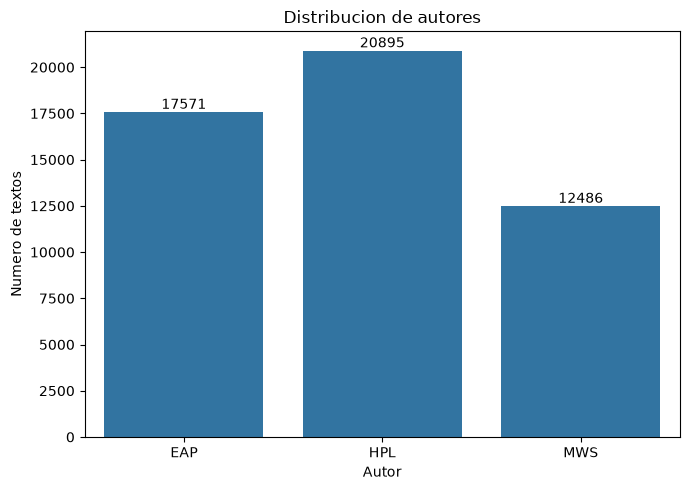

author
HPL    20895
EAP    17571
MWS    12486
Name: count, dtype: int64


In [4]:
"""Carga el conjunto de datos desde Kaggle. Guarda los textos y autores en un DataFrame. 
Luego muestra la cantidad de textos por autor."""

path = kagglehub.dataset_download("lteodor/identify-the-author")
csv_path = Path(path) / "labeled_sentence_corpus.csv"
df = pd.read_csv(csv_path)

plt.figure(figsize=(7, 5))

ax = sns.countplot(x="author", data=df)

plt.title("Distribucion de autores")
plt.xlabel("Autor")
plt.ylabel("Numero de textos")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

print(df["author"].value_counts())


In [22]:
df

,text,author,processed_text
0,"I am as positive that yesterday was Sunday as I am that I sit upon this chair.""",EAP,posit yesterday sunday sit upon chair
1,"""By the Waters of the Brook,"" by Rev.",HPL,water brook rev
2,Even for thy woes I love thee-even for thy woes- Thy beauty and thy woes.,EAP,even thi woe love thee even thi woe thi beauti thi woe
3,Negotium perambulans in tenebris.,HPL,negotium perambulan tenebri
4,"Perdita tried to read his countenance, which he angrily averted.",MWS,perdita tri read counten angrili avert
...,...,...,...
50947,The paradisal scenes were almost too extravagant to be believed; portraying a hidden world of et...,HPL,paradis scene almost extravag believ portray hidden world etern day fill glorious citi ether hil...
50948,It was as if there were regular lines of composite impressions - impressions that went in threes...,HPL,regular line composit impress impress went three slight foot squar consist five near circular th...
50949,"Upon my recovery, too, I felt very-oh!",EAP,upon recoveri felt oh
50950,"We kept on in this manner throughout the day, with no material incident, and, as the shades of n...",EAP,kept manner throughout day materi incid shade night close around us made rough estim distanc tra...


In [5]:
"""Preprocesa los textos para reducir el ruido. Elimina caracteres innecesarios. 
Convierte el texto a minusculas. Elimina palabras de parada y aplica stemming."""

def preprocess(text):
    """Clean, lowercase and stem an English message."""
    # Paso 1: Remover con una expresión regular caracteres especiales (no palabras).
    processed = re.sub(r"\W", " ", str(text))
    # Paso 2: Remover ocurrencias de caracteres individuales.
    processed = re.sub(r"\s+[a-zA-Z]\s+", " ", processed)
    # Paso 3: Remover numeros.
    processed = re.sub(r"[0-9]+", " ", processed)
    # Paso 4: Simplificar espacios consecutivos a un unico espacio entre palabras.
    processed = re.sub(r" +", " ", processed)
    # Paso 5: Pasar todo el texto a minusculas.
    processed = processed.lower()
    # Paso 6: Remover palabras de parada y aplicar stemming.
    return " ".join(
        stemmer.stem(token)
        for token in processed.split()
        if token not in english_stopwords
    )

df["processed_text"] = df["text"].apply(preprocess)

In [6]:
"""Divide los datos en conjuntos de entrenamiento. Validacion y prueba. 
Mantiene la proporcion de textos de cada autor en los tres conjuntos."""

#train_df → 60%
#val_df   → 10%
#test_df  → 30%

train_df, aux_df = train_test_split(
    df,
    test_size=0.40,
    random_state=42,
    stratify=df["author"],
)

val_df, test_df = train_test_split(
    aux_df,
    test_size=0.75,
    random_state=42,
    stratify=aux_df["author"],
)

X_train = train_df["processed_text"]
y_train = train_df["author"]

X_val = val_df["processed_text"]
y_val = val_df["author"]

X_test = test_df["processed_text"]
y_test = test_df["author"]

In [7]:
"""Convierte los textos en vectores TF IDF usando palabras. 
Ajusta el vectorizador solo con los datos de entrenamiento. 
Luego transforma validacion y prueba."""

#TF-IDF de palabras
vectorizer_word = TfidfVectorizer()

X_train_word = vectorizer_word.fit_transform(X_train)
X_val_word = vectorizer_word.transform(X_val)
X_test_word = vectorizer_word.transform(X_test)

print("Train:", X_train_word.shape)
print("Validation:", X_val_word.shape)
print("Test:", X_test_word.shape)

Train: (30571, 18878)
Validation: (5095, 18878)
Test: (15286, 18878)


In [8]:
"""Convierte los textos en vectores TF IDF usando grupos de caracteres de 
tres a cinco caracteres. Ajusta el vectorizador con entrenamiento y transforma 
los otros conjuntos."""

#TF-IDF de palabras con n-gramas en donde n -> 3..5
vectorizer_char = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5)
)

X_train_char = vectorizer_char.fit_transform(X_train)
X_val_char = vectorizer_char.transform(X_val)
X_test_char = vectorizer_char.transform(X_test)

print("Train:", X_train_char.shape)
print("Validation:", X_val_char.shape)
print("Test:", X_test_char.shape)

Train: (30571, 178070)
Validation: (5095, 178070)
Test: (15286, 178070)


### Naive Bayes

#### Entrenamiento con TF-IDF (Palabras)

In [9]:
"""Entrena varios modelos Naive Bayes usando TF IDF de palabras. 
Cambia el valor de alpha y guarda el F1 macro de entrenamiento y 
validacion para cada modelo."""

valores_alpha = [0.01, 0.1, 0.5, 1, 5, 10]
resultados_nb_word = []

for alpha in valores_alpha:
    #Crear el modelo a partir del alpha variable
    modelo = MultinomialNB(alpha=alpha)
    #Entrenar el modelo
    modelo.fit(X_train_word, y_train)
    #Evaluar el modelo
    pred_train = modelo.predict(X_train_word)
    pred_val = modelo.predict(X_val_word)

    f1_train = f1_score(y_train, pred_train, average="macro")
    f1_val = f1_score(y_val, pred_val, average="macro")

    resultados_nb_word.append({
        "Alpha": alpha,
        "Train F1 macro": f1_train,
        "Validation F1 macro": f1_val
    })

In [10]:
resultados_nb_word = pd.DataFrame(resultados_nb_word)
resultados_nb_word

,Alpha,Train F1 macro,Validation F1 macro
0,0.01,0.910675,0.828801
1,0.10,0.904267,0.832616
2,0.50,0.889839,0.823226
3,1.00,0.872942,0.811528
4,5.00,0.760219,0.717424
5,10.00,0.672233,0.636519


Aqui se ve un comportamiento bastante claro: con alpha=0.01, el F1 de validacion es 0.829, pero aumenta ligeramente a 0.833 con alpha=0.1, que es el mejor resultado. A partir de ahi, al incrementar alpha, el rendimiento disminuye progresivamente. Esto indica que una suavizacion demasiado fuerte perjudica al modelo, mientras que una suavizacion moderada mejora la generalizacion. Ademas, la diferencia entre train y validation es relativamente pequeña en alpha=0.1, por lo que alpha=0.1 presenta el mejor equilibrio en este experimento.

#### Entrenamiento con TF-IDF (Caracteres)

In [11]:
"""Entrena varios modelos Naive Bayes usando TF IDF de caracteres. 
Cambia el valor de alpha y guarda el F1 macro de entrenamiento y 
validacion para cada modelo."""

valores_alpha = [0.01, 0.1, 0.5, 1, 5, 10]
resultados_nb_char = []

for alpha in valores_alpha:
    modelo = MultinomialNB(alpha=alpha)

    modelo.fit(X_train_char, y_train)

    pred_train = modelo.predict(X_train_char)
    pred_val = modelo.predict(X_val_char)

    f1_train = f1_score(y_train, pred_train, average="macro")
    f1_val = f1_score(y_val, pred_val, average="macro")

    resultados_nb_char.append({
        "Alpha": alpha,
        "Train F1 macro": f1_train,
        "Validation F1 macro": f1_val
    })


In [12]:
resultados_nb_char = pd.DataFrame(resultados_nb_char)
resultados_nb_char

,Alpha,Train F1 macro,Validation F1 macro
0,0.01,0.932429,0.812059
1,0.10,0.905344,0.805067
2,0.50,0.844135,0.753302
3,1.00,0.749212,0.673294
4,5.00,0.437429,0.377398
5,10.00,0.332507,0.293641


En caracteres, el mejor resultado de validacion se obtiene con alpha=0.01, con un F1 de 0.812. A medida que aumenta alpha, tanto el F1 de entrenamiento como el de validacion disminuyen, lo que indica que una mayor suavizacion perjudica el rendimiento del modelo. Ademas, la diferencia entre entrenamiento y validacion es mayor con alpha=0.01, pero sigue siendo el valor que ofrece el mejor desempeño de validacion en este experimento.

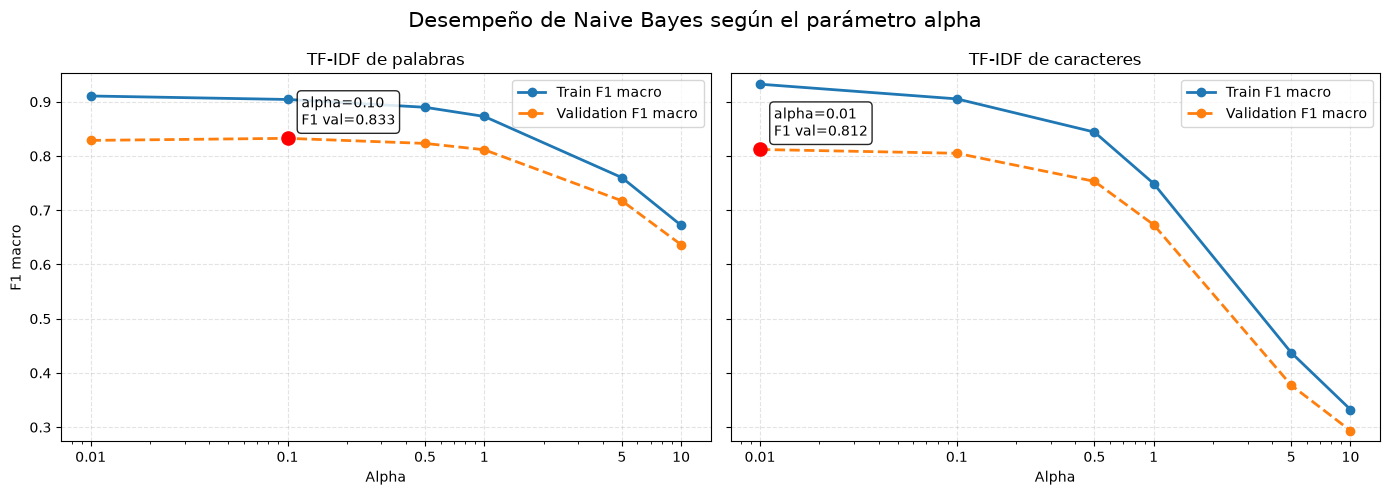

In [36]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import ScalarFormatter

# Ordenar los resultados por alpha
nb_word = resultados_nb_word.sort_values("Alpha")
nb_char = resultados_nb_char.sort_values("Alpha")

# Rango Y común para ambos paneles
f1_nb = pd.concat([
    nb_word["Train F1 macro"],
    nb_word["Validation F1 macro"],
    nb_char["Train F1 macro"],
    nb_char["Validation F1 macro"]
])

y_min = f1_nb.min() - 0.02
y_max = f1_nb.max() + 0.02

fig, axes = plt.subplots(
    ncols=2,
    figsize=(14, 5),
    sharey=True
)

configuraciones_nb = [
    (axes[0], nb_word, "TF-IDF de palabras"),
    (axes[1], nb_char, "TF-IDF de caracteres")
]

for ax, resultados, titulo in configuraciones_nb:

    ax.plot(
        resultados["Alpha"],
        resultados["Train F1 macro"],
        marker="o",
        linewidth=2,
        label="Train F1 macro"
    )

    ax.plot(
        resultados["Alpha"],
        resultados["Validation F1 macro"],
        marker="o",
        linestyle="--",
        linewidth=2,
        label="Validation F1 macro"
    )

    # Mejor resultado de validación
    mejor_idx = resultados["Validation F1 macro"].idxmax()
    mejor = resultados.loc[mejor_idx]

    ax.scatter(
        mejor["Alpha"],
        mejor["Validation F1 macro"],
        color="red",
        s=90,
        zorder=5
    )

    ax.annotate(
        f"alpha={mejor['Alpha']:.2f}\n"
        f"F1 val={mejor['Validation F1 macro']:.3f}",
        xy=(
            mejor["Alpha"],
            mejor["Validation F1 macro"]
        ),
        xytext=(10, 10),
        textcoords="offset points",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            alpha=0.85
        )
    )

    # Escala logarítmica
    ax.set_xscale("log")

    # Mostrar los valores de alpha en decimal
    ticks_alpha = sorted(resultados["Alpha"].unique())

    ax.set_xticks(ticks_alpha)
    ax.set_xticklabels(
        [f"{alpha:g}" for alpha in ticks_alpha]
    )

    ax.set_xlabel("Alpha")
    ax.set_title(titulo)
    ax.set_ylim(y_min, y_max)
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend()

axes[0].set_ylabel("F1 macro")

fig.suptitle(
    "Desempeño de Naive Bayes según el parámetro alpha",
    fontsize=15
)

plt.tight_layout()
plt.show()

### Regresion logistica

#### Entrenamiento con TF-IDF (Palabras)

In [13]:
"""Entrena varios modelos de regresion logistica usando TF IDF de palabras. 
Cambia el valor de alpha y del "learning rate"  y guarda el F1 macro de entrenamiento y 
validacion para cada modelo."""

valores_learning_rate = ["constant", "optimal", "invscaling", "adaptive"]
valores_alpha = [0.000001, 0.00001, 0.0001, 0.001, 0.01]

resultados_lr_word = []

for learning_rate in valores_learning_rate:
    for alpha in valores_alpha:
        modelo = SGDClassifier(
            loss="log_loss",
            learning_rate=learning_rate,
            alpha=alpha,
            eta0=0.0001,
            random_state=0
        )

        modelo.fit(X_train_word, y_train)

        pred_train = modelo.predict(X_train_word)
        pred_val = modelo.predict(X_val_word)

        f1_train = f1_score(y_train, pred_train, average="macro")
        f1_val = f1_score(y_val, pred_val, average="macro")

        resultados_lr_word.append({
            "Learning rate": learning_rate,
            "Alpha": alpha,
            "Train F1 macro": f1_train,
            "Validation F1 macro": f1_val
        })



In [14]:
resultados_lr_word = pd.DataFrame(resultados_lr_word)
resultados_lr_word

,Learning rate,Alpha,Train F1 macro,Validation F1 macro
0,constant,0.000001,0.194021,0.193857
1,constant,0.000010,0.194021,0.193857
2,constant,0.000100,0.194021,0.193857
3,constant,0.001000,0.194021,0.193857
4,constant,0.010000,0.194088,0.193857
5,optimal,0.000001,0.969833,0.825385
6,optimal,0.000010,0.922939,0.828904
7,optimal,0.000100,0.834284,0.785584
8,optimal,0.001000,0.584084,0.567150
9,optimal,0.010000,0.196320,0.194290


Con TF-IDF de palabras, el mejor resultado se obtiene con learning_rate="optimal" y alpha=0.00001, alcanzando un F1 de validacion de 0.829. Los otros tipos de learning_rate tienen resultados bastante bajos, especialmente constant y adaptive, que se mantienen cerca de 0.194. Tambien se observa que aumentar demasiado alpha reduce el rendimiento del modelo. Con alpha=0.000001 el F1 de entrenamiento es mayor (0.970), pero la validacion es menor (0.825), mientras que con alpha=0.00001 el entrenamiento baja a 0.923 pero la validacion sube a 0.829. Esto muestra que una pequeña cantidad de regularizacion ayuda a que el modelo generalice mejor.

#### Entrenamiento con TF-IDF (Caracteres)

In [15]:
"""Entrena varios modelos de regresion logistica usando TF IDF de caracteres. 
Cambia el valor de alpha y del "learning_rate" y guarda el F1 macro de entrenamiento y 
validacion para cada modelo."""

valores_learning_rate = ["constant", "optimal", "invscaling", "adaptive"]
valores_alpha = [0.000001, 0.00001, 0.0001, 0.001, 0.01]

resultados_lr_char = []

for learning_rate in valores_learning_rate:
    for alpha in valores_alpha:
        modelo = SGDClassifier(
            loss="log_loss",
            learning_rate=learning_rate,
            alpha=alpha,
            eta0=0.0001,
            random_state=0
        )

        modelo.fit(X_train_char, y_train)

        pred_train = modelo.predict(X_train_char)
        pred_val = modelo.predict(X_val_char)

        f1_train = f1_score(y_train, pred_train, average="macro")
        f1_val = f1_score(y_val, pred_val, average="macro")

        resultados_lr_char.append({
            "Learning rate": learning_rate,
            "Alpha": alpha,
            "Train F1 macro": f1_train,
            "Validation F1 macro": f1_val
        })


In [16]:
resultados_lr_char = pd.DataFrame(resultados_lr_char)
resultados_lr_char

,Learning rate,Alpha,Train F1 macro,Validation F1 macro
0,constant,0.000001,0.193885,0.193857
1,constant,0.000010,0.193885,0.193857
2,constant,0.000100,0.193885,0.193857
3,constant,0.001000,0.193885,0.193857
4,constant,0.010000,0.193885,0.193857
5,optimal,0.000001,0.999897,0.813298
6,optimal,0.000010,0.953506,0.808292
7,optimal,0.000100,0.815734,0.748130
8,optimal,0.001000,0.516708,0.478941
9,optimal,0.010000,0.194021,0.193857


Con TF-IDF de caracteres, el mejor resultado se obtiene con learning_rate="optimal" y alpha=0.000001, alcanzando un F1 de validacion de 0.813. En entrenamiento obtiene 0.999897, mientras que en validacion baja a 0.813, mostrando una diferencia bastante grande entre ambos resultados y un claro sobreajuste. Al aumentar alpha, tanto el F1 de entrenamiento como el de validacion disminuyen. Ademas, los otros tipos de learning_rate tienen resultados muy bajos, cercanos a 0.19. En este caso, la representacion de caracteres no alcanza el 0.82 solicitado en validacion.

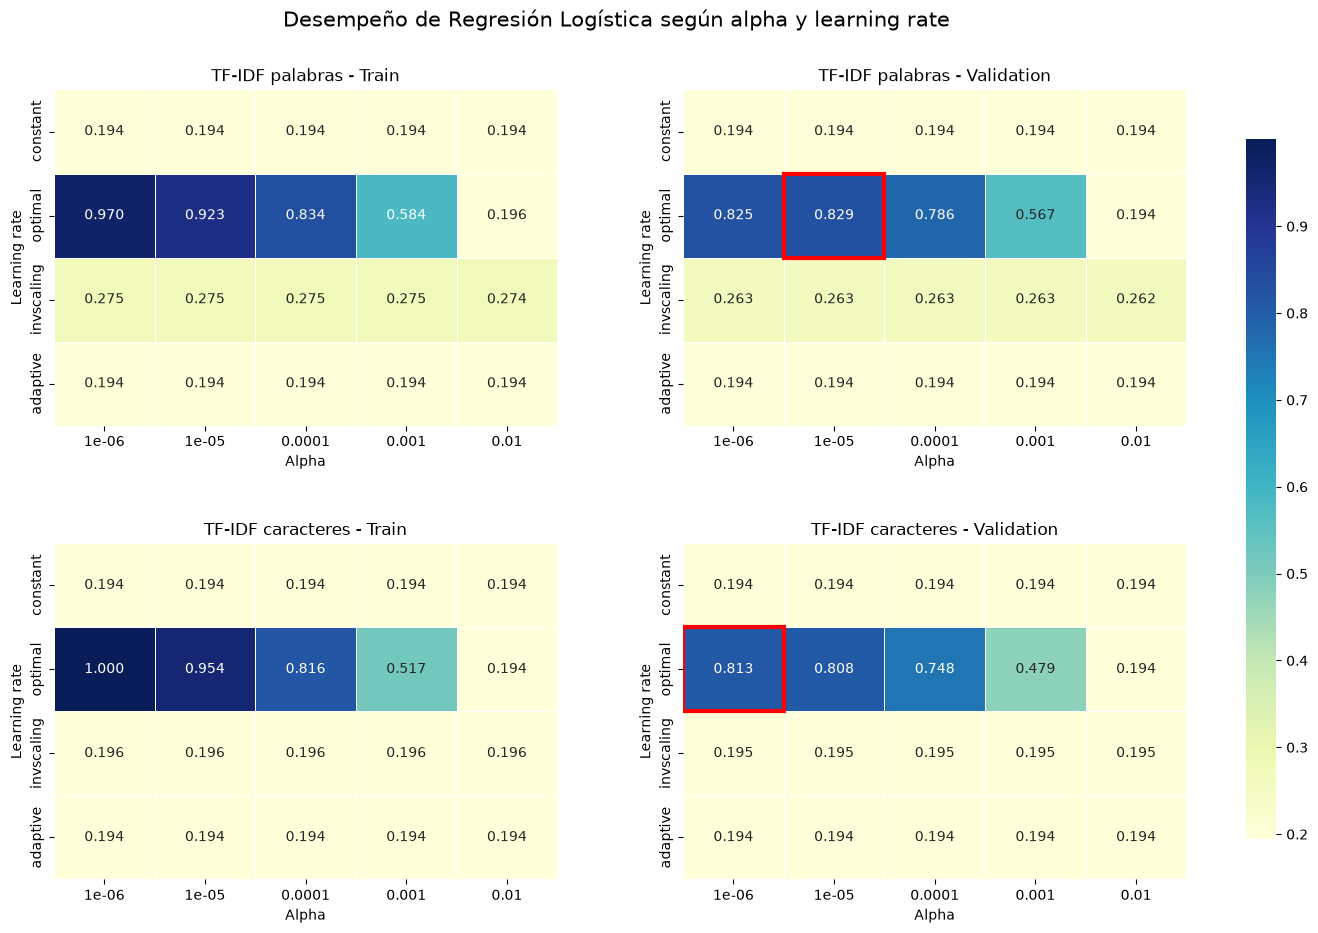

In [35]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Rectangle

orden_learning_rate = [
    "constant",
    "optimal",
    "invscaling",
    "adaptive"
]

# Alfa ordenado numéricamente y compartido por todos los mapas
todos_los_resultados_lr = pd.concat([
    resultados_lr_word,
    resultados_lr_char
])

orden_alpha = sorted(
    todos_los_resultados_lr["Alpha"].unique()
)

# Rango de colores común para los cuatro mapas
todos_los_f1 = pd.concat([
    resultados_lr_word["Train F1 macro"],
    resultados_lr_word["Validation F1 macro"],
    resultados_lr_char["Train F1 macro"],
    resultados_lr_char["Validation F1 macro"]
])

vmin = todos_los_f1.min()
vmax = todos_los_f1.max()

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(15, 10)
)

configuraciones_lr = [
    (
        axes[0, 0],
        resultados_lr_word,
        "Train F1 macro",
        "TF-IDF palabras - Train",
        "Train F1 macro",
        False
    ),
    (
        axes[0, 1],
        resultados_lr_word,
        "Validation F1 macro",
        "TF-IDF palabras - Validation",
        "Validation F1 macro",
        True
    ),
    (
        axes[1, 0],
        resultados_lr_char,
        "Train F1 macro",
        "TF-IDF caracteres - Train",
        "Train F1 macro",
        False
    ),
    (
        axes[1, 1],
        resultados_lr_char,
        "Validation F1 macro",
        "TF-IDF caracteres - Validation",
        "Validation F1 macro",
        True
    )
]

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])

for i, (
    ax,
    resultados,
    columna_valor,
    titulo,
    etiqueta,
    marcar_mejor
) in enumerate(configuraciones_lr):

    tabla = resultados.pivot(
        index="Learning rate",
        columns="Alpha",
        values=columna_valor
    )

    tabla = tabla.reindex(index=orden_learning_rate)
    tabla = tabla.reindex(columns=orden_alpha)

    sns.heatmap(
        tabla,
        ax=ax,
        annot=True,
        fmt=".3f",
        cmap="YlGnBu",
        vmin=vmin,
        vmax=vmax,
        linewidths=0.5,
        linecolor="white",
        cbar=(i == 0),
        cbar_ax=cbar_ax if i == 0 else None
    )

    ax.set_title(titulo)
    ax.set_xlabel("Alpha")
    ax.set_ylabel("Learning rate")

    if marcar_mejor:
        mejor_idx = resultados["Validation F1 macro"].idxmax()
        mejor = resultados.loc[mejor_idx]

        fila = orden_learning_rate.index(
            mejor["Learning rate"]
        )
        columna = list(tabla.columns).index(
            mejor["Alpha"]
        )

        ax.add_patch(
            Rectangle(
                (columna, fila),
                1,
                1,
                fill=False,
                edgecolor="red",
                linewidth=3
            )
        )

fig.suptitle(
    "Desempeño de Regresión Logística según alpha y learning rate",
    fontsize=15
)

fig.subplots_adjust(
    top=0.90,
    right=0.88,
    wspace=0.25,
    hspace=0.35
)

plt.show()

### Resumen de la evaluacion de los modelos

In [17]:
"""Construye un resumen con la mejor configuracion de cada modelo.

Incluye los hiperparametros y el F1 macro de entrenamiento y validacion.
"""

resumen = pd.DataFrame([
    [
        "Naive Bayes",
        "Palabras",
        "-",
        resultados_nb_word.loc[
            resultados_nb_word["Validation F1 macro"].idxmax(), "Alpha"
        ],
        resultados_nb_word.loc[
            resultados_nb_word["Validation F1 macro"].idxmax(), "Train F1 macro"
        ],
        resultados_nb_word["Validation F1 macro"].max()
    ],
    [
        "Naive Bayes",
        "Caracteres",
        "-",
        resultados_nb_char.loc[
            resultados_nb_char["Validation F1 macro"].idxmax(), "Alpha"
        ],
        resultados_nb_char.loc[
            resultados_nb_char["Validation F1 macro"].idxmax(), "Train F1 macro"
        ],
        resultados_nb_char["Validation F1 macro"].max()
    ],
    [
        "Logistic Regression",
        "Palabras",
        resultados_lr_word.loc[
            resultados_lr_word["Validation F1 macro"].idxmax(), "Learning rate"
        ],
        resultados_lr_word.loc[
            resultados_lr_word["Validation F1 macro"].idxmax(), "Alpha"
        ],
        resultados_lr_word.loc[
            resultados_lr_word["Validation F1 macro"].idxmax(), "Train F1 macro"
        ],
        resultados_lr_word["Validation F1 macro"].max()
    ],
    [
        "Logistic Regression",
        "Caracteres",
        resultados_lr_char.loc[
            resultados_lr_char["Validation F1 macro"].idxmax(), "Learning rate"
        ],
        resultados_lr_char.loc[
            resultados_lr_char["Validation F1 macro"].idxmax(), "Alpha"
        ],
        resultados_lr_char.loc[
            resultados_lr_char["Validation F1 macro"].idxmax(), "Train F1 macro"
        ],
        resultados_lr_char["Validation F1 macro"].max()
    ]
], columns=[
    "Modelo",
    "Representacion",
    "Learning rate",
    "Alpha",
    "Train F1 macro",
    "Validation F1 macro"
])

resumen

,Modelo,Representacion,Learning rate,Alpha,Train F1 macro,Validation F1 macro
0,Naive Bayes,Palabras,-,0.100000,0.904267,0.832616
1,Naive Bayes,Caracteres,-,0.010000,0.932429,0.812059
2,Logistic Regression,Palabras,optimal,0.000010,0.922939,0.828904
3,Logistic Regression,Caracteres,optimal,0.000001,0.999897,0.813298


La tabla muestra que Naive Bayes con palabras obtiene el mejor F1 de validacion con 0.833, seguido de Logistic Regression con palabras con 0.829. Las representaciones de caracteres tienen resultados menores, y en especial Logistic Regression presenta una diferencia grande entre entrenamiento y validacion, lo que muestra sobreajuste. Por esto, la configuracion seleccionada es Naive Bayes con TF-IDF de palabras y alpha=0.10, ya que obtiene el mejor resultado de validacion.

Por lo tanto, la configuracion seleccionada para la evaluacion final es:

Modelo: Naive Bayes

Representacion: TF-IDF de palabras

alpha: 0.10

Validation F1 macro: 0.832616

### Construccion del modelo a usar

In [18]:
"""Obtiene automaticamente el alpha que produjo el mejor F1 macro de validacion. 
Con ese valor crea el modelo final. Luego entrena el modelo y genera las predicciones 
del conjunto de prueba."""

mejor_alpha = resultados_nb_word.loc[
    resultados_nb_word["Validation F1 macro"].idxmax(),
    "Alpha"
]
nb_final = MultinomialNB(alpha=mejor_alpha)

nb_final.fit(X_train_word, y_train)

pred_nb_test = nb_final.predict(X_test_word)

#### Evaluacion

In [19]:
"""Calcula el Accuracy y muestra el reporte de clasificacion del modelo final sobre el conjunto 
de prueba."""

print("Accuracy:", accuracy_score(y_test, pred_nb_test))

print(
    classification_report(
        y_test,
        pred_nb_test,
        digits=3
    )
)

Accuracy: 0.8447599110297004
              precision    recall  f1-score   support

         EAP      0.831     0.807     0.819      5272
         HPL      0.859     0.903     0.881      6269
         MWS      0.837     0.801     0.818      3745

    accuracy                          0.845     15286
   macro avg      0.843     0.837     0.839     15286
weighted avg      0.844     0.845     0.844     15286



El modelo obtuvo un Accuracy de 0.845, lo que significa que aproximadamente el 84.5% de las predicciones realizadas sobre el conjunto de test fueron correctas. Esto muestra que el modelo logra clasificar correctamente la mayoria de los textos, aunque todavia existe un porcentaje de casos donde confunde entre los diferentes autores.

In [20]:
"""Calcula el F1 micro y el F1 macro del modelo final sobre el conjunto de prueba."""

f1_micro = f1_score(
    y_test,
    pred_nb_test,
    average="micro"
)
f1_macro = f1_score(
    y_test,
    pred_nb_test,
    average="macro"
)
print("F1 micro:", f1_micro)
print("F1 macro:", f1_macro)

F1 micro: 0.8447599110297004
F1 macro: 0.8393447723184745


El F1 micro fue de 0.845, lo que indica un buen desempeño considerando todas las predicciones en conjunto. Ademas, el F1 macro fue de 0.839, superando el 0.82 solicitado. El F1 micro es muy similar al Accuracy (0.845), lo que muestra que el rendimiento general del modelo es consistente.

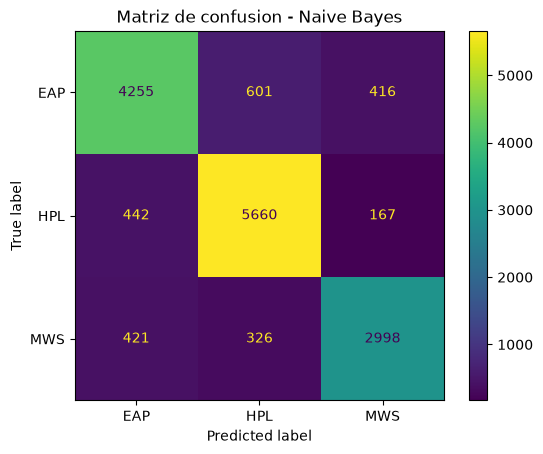

In [37]:
"""Calcula la matriz de confusion del modelo final. Luego muestra la cantidad de predicciones correctas y errores para cada autor."""

cm = confusion_matrix(y_test, pred_nb_test)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=nb_final.classes_
).plot()

plt.title("Matriz de confusion - Naive Bayes")
plt.show()

La matriz de confusion permite ver no solo cuantos textos clasifica bien el modelo, sino tambien que tan facil o dificil es diferenciar a cada autor. HPL es el autor que el modelo identifica con mayor facilidad, ya que acierta 5660 de 6269 textos, y solo confunde 442 con EAP y 167 con MWS. Esto sugiere que las caracteristicas presentes en los textos de HPL son relativamente mas faciles de distinguir de las de los otros autores. En cambio, EAP presenta mas dificultad, especialmente porque 601 textos de EAP son clasificados como HPL, siendo la confusion mas grande de toda la matriz. Esto significa que existe una mayor similitud entre las caracteristicas que el modelo aprendio de EAP y HPL. Algo parecido ocurre con MWS, donde 421 textos son confundidos con EAP y 326 con HPL, por lo que sus caracteristicas son menos faciles de separar. En general, la matriz muestra que el modelo no tiene un problema general para clasificar los autores, sino que sus principales dificultades aparecen cuando debe diferenciar autores que tienen caracteristicas textuales similares. Esto tambien ayuda a explicar por que el F1 macro es 0.839: aunque el rendimiento global es bueno y supera el 0.82 solicitado, no todos los autores son reconocidos con la misma facilidad.